# **CIFAR-10 Image Classification using CNN and ResNet-style Model**

This Google Colab notebook performs image classification on the  **CIFAR-10** dataset.


## **1. Import libraries**

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Activation,
    Add,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("TensorFlow version:", tf.__version__)
print("GPU Available:", len(tf.config.list_physical_devices("GPU")) > 0)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

TensorFlow version: 2.20.0
GPU Available: True


## **2. Load CIFAR-10 dataset**

In [4]:
# ============================================================
# 2. Load CIFAR-10 Dataset - Safe Version Without TFDS Error
# ============================================================

import os
import shutil
from tensorflow.keras.datasets import cifar10

# CIFAR-10 class names
CLASS_NAMES = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

NUM_CLASSES = len(CLASS_NAMES)

# ------------------------------------------------------------
# CIFAR-10 is built into Keras.
# This will download only once. After download, it will load from cache.
# ------------------------------------------------------------

print("Loading CIFAR-10 dataset...")

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Dataset loaded successfully!")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\nNumber of classes:", NUM_CLASSES)
print("Class names:", CLASS_NAMES)

Loading CIFAR-10 dataset...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 7076s 42us/step
Dataset loaded successfully!
X_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
X_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)

Number of classes: 10
Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## **3. Dataset description**

In [8]:
# Flatten labels for analysis and evaluation
y_train_flat = y_train.flatten()
y_test_flat = y_test.flatten()

print("CIFAR-10 Dataset Description")
print("-" * 40)
print("Number of training images:", X_train.shape[0])
print("Number of testing images:", X_test.shape[0])
print("Image size:", X_train.shape[1], "x", X_train.shape[2])
print("Color channels:", X_train.shape[3])
print("Number of classes:", NUM_CLASSES)
print("Class names:", CLASS_NAMES)
print("Pixel value range before normalization:", X_train.min(), "to", X_train.max())

train_distribution = pd.Series(y_train_flat).value_counts().sort_index()
test_distribution = pd.Series(y_test_flat).value_counts().sort_index()

distribution_df = pd.DataFrame({
    "Class ID": range(NUM_CLASSES),
    "Class Name": CLASS_NAMES,
    "Training Images": [train_distribution.get(i, 0) for i in range(NUM_CLASSES)],
    "Testing Images": [test_distribution.get(i, 0) for i in range(NUM_CLASSES)]
})

display(distribution_df)

CIFAR-10 Dataset Description
----------------------------------------
Number of training images: 50000
Number of testing images: 10000
Image size: 32 x 32
Color channels: 3
Number of classes: 10
Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Pixel value range before normalization: 0 to 255


,Class ID,Class Name,Training Images,Testing Images
0,0,airplane,5000,1000
1,1,automobile,5000,1000
2,2,bird,5000,1000
3,3,cat,5000,1000
4,4,deer,5000,1000
5,5,dog,5000,1000
6,6,frog,5000,1000
7,7,horse,5000,1000
8,8,ship,5000,1000
9,9,truck,5000,1000


## **4. Show sample images**

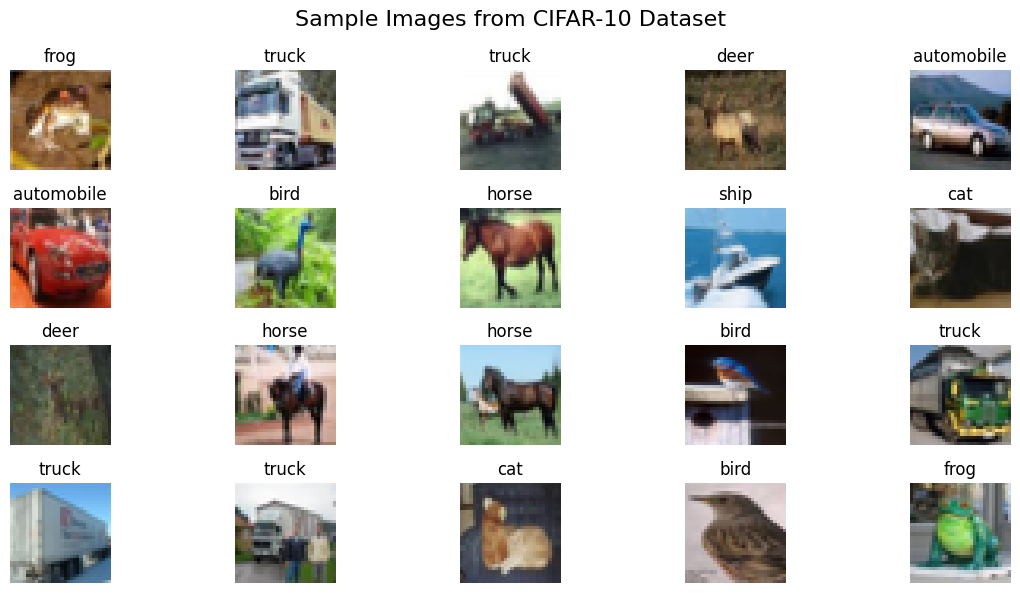

In [9]:
plt.figure(figsize=(12, 6))

for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(X_train[i])
    label_id = int(y_train_flat[i])
    plt.title(CLASS_NAMES[label_id])
    plt.axis("off")

plt.suptitle("Sample Images from CIFAR-10 Dataset", fontsize=16)
plt.tight_layout()
plt.show()

## **5. Normalize image data**

In [10]:
# Convert pixel values from 0-255 to 0-1
X_train_norm = X_train.astype("float32") / 255.0
X_test_norm = X_test.astype("float32") / 255.0

print("Pixel value range after normalization:")
print("Training data:", X_train_norm.min(), "to", X_train_norm.max())
print("Testing data:", X_test_norm.min(), "to", X_test_norm.max())

Pixel value range after normalization:
Training data: 0.0 to 1.0
Testing data: 0.0 to 1.0


## **6. One-hot encode labels**

In [11]:
# One-hot encoding converts labels like 3 into [0,0,0,1,0,0,0,0,0,0]
y_train_cat = to_categorical(y_train_flat, NUM_CLASSES)
y_test_cat = to_categorical(y_test_flat, NUM_CLASSES)

print("Original label example:", y_train_flat[0])
print("One-hot encoded example:", y_train_cat[0])
print("y_train_cat shape:", y_train_cat.shape)
print("y_test_cat shape:", y_test_cat.shape)

Original label example: 6
One-hot encoded example: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
y_train_cat shape: (50000, 10)
y_test_cat shape: (10000, 10)


## **7. Helper functions for evaluation and plotting**

In [12]:
model_results = {}

def plot_training_history(history, model_name):
    """Plot accuracy and loss curves for a trained model."""
    hist = history.history

    plt.figure(figsize=(8, 5))
    plt.plot(hist["accuracy"], label="Training Accuracy")
    plt.plot(hist["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{model_name} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(hist["loss"], label="Training Loss")
    plt.plot(hist["val_loss"], label="Validation Loss")
    plt.title(f"{model_name} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()


def evaluate_model(model, X_test_data, y_test_onehot, y_test_original, model_name, show_matrix=True):
    """Evaluate model, print accuracy, classification report, and confusion matrix."""
    print(f"\n===== {model_name} Evaluation =====")

    test_loss, test_accuracy = model.evaluate(X_test_data, y_test_onehot, verbose=0)
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")

    y_pred_prob = model.predict(X_test_data, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)

    print("\nClassification Report:")
    print(
        classification_report(
            y_test_original,
            y_pred,
            labels=list(range(NUM_CLASSES)),
            target_names=CLASS_NAMES,
            zero_division=0
        )
    )

    if show_matrix:
        cm = confusion_matrix(
            y_test_original,
            y_pred,
            labels=list(range(NUM_CLASSES))
        )

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=CLASS_NAMES
        )

        fig, ax = plt.subplots(figsize=(10, 8))
        disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, values_format="d")
        plt.title(f"Confusion Matrix - {model_name}")
        plt.show()

    model_results[model_name] = {
        "Test Loss": test_loss,
        "Test Accuracy": test_accuracy
    }

    return y_pred, test_accuracy


def show_random_predictions(model, X_data, y_original, model_name, total_images=10):
    """Show random test images with actual and predicted labels."""
    indices = np.random.choice(len(X_data), size=total_images, replace=False)

    plt.figure(figsize=(15, 5))

    for i, idx in enumerate(indices):
        image = X_data[idx]
        actual_label = int(y_original[idx])

        pred_prob = model.predict(np.expand_dims(image, axis=0), verbose=0)
        pred_label = int(np.argmax(pred_prob, axis=1)[0])

        plt.subplot(2, 5, i + 1)
        plt.imshow(image)
        plt.axis("off")

        title_color = "green" if actual_label == pred_label else "red"
        plt.title(
            f"Actual: {CLASS_NAMES[actual_label]}\nPred: {CLASS_NAMES[pred_label]}",
            color=title_color,
            fontsize=10
        )

    plt.suptitle(f"Random Image Predictions - {model_name}", fontsize=16)
    plt.tight_layout()
    plt.show()

## **8. Build CNN model**

In [13]:
def build_cnn_model(input_shape=(32, 32, 3), num_classes=10):
    model = Sequential([
        Input(shape=input_shape),

        Conv2D(32, (3, 3), padding="same"),
        BatchNormalization(),
        Activation("relu"),
        Conv2D(32, (3, 3), padding="same"),
        BatchNormalization(),
        Activation("relu"),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        Conv2D(64, (3, 3), padding="same"),
        BatchNormalization(),
        Activation("relu"),
        Conv2D(64, (3, 3), padding="same"),
        BatchNormalization(),
        Activation("relu"),
        MaxPooling2D((2, 2)),
        Dropout(0.30),

        Conv2D(128, (3, 3), padding="same"),
        BatchNormalization(),
        Activation("relu"),
        Conv2D(128, (3, 3), padding="same"),
        BatchNormalization(),
        Activation("relu"),
        MaxPooling2D((2, 2)),
        Dropout(0.40),

        GlobalAveragePooling2D(),
        Dense(128, activation="relu"),
        Dropout(0.50),
        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


cnn_model = build_cnn_model(num_classes=NUM_CLASSES)
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 8, 8, 128)      │             

 Total params: 306,602 (1.17 MB)

 Trainable params: 305,706 (1.17 MB)

 Non-trainable params: 896 (3.50 KB)

## **9. Train CNN model**

In [14]:
# You can increase epochs for better accuracy.
# For quick Colab execution, 10 epochs is a safe starting point.

CNN_EPOCHS = 10
BATCH_SIZE = 64

cnn_callbacks = [
    EarlyStopping(
        monitor="val_accuracy",
        patience=4,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]

cnn_history = cnn_model.fit(
    X_train_norm,
    y_train_cat,
    validation_split=0.2,
    epochs=CNN_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=cnn_callbacks,
    verbose=1
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.4230 - loss: 1.5699 - val_accuracy: 0.5271 - val_loss: 1.3034 - learning_rate: 0.0010
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.5777 - loss: 1.1815 - val_accuracy: 0.4250 - val_loss: 1.8398 - learning_rate: 0.0010
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6286 - loss: 1.0516 - val_accuracy: 0.5394 - val_loss: 1.2929 - learning_rate: 0.0010
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.6585 - loss: 0.9696 - val_accuracy: 0.6158 - val_loss: 1.0635 - learning_rate: 0.0010
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6806 - loss: 0.9083 - val_accuracy: 0.6751 - val_loss: 0.8983 - learning_rate: 0.0010
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7042 - loss: 0.8489 - val_accuracy: 0.6752 - val_loss: 0.8838 - learning_rate: 0.0010
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7193 - loss: 0.80

## **10. Evaluate CNN model**


===== CNN Evaluation =====
Test Loss: 0.7216
Test Accuracy: 0.7366

Classification Report:
              precision    recall  f1-score   support

    airplane       0.85      0.66      0.75      1000
  automobile       0.89      0.89      0.89      1000
        bird       0.50      0.83      0.62      1000
         cat       0.55      0.60      0.58      1000
        deer       0.89      0.49      0.63      1000
         dog       0.67      0.59      0.62      1000
        frog       0.83      0.75      0.79      1000
       horse       0.76      0.83      0.79      1000
        ship       0.79      0.92      0.85      1000
       truck       0.93      0.81      0.87      1000

    accuracy                           0.74     10000
   macro avg       0.77      0.74      0.74     10000
weighted avg       0.77      0.74      0.74     10000



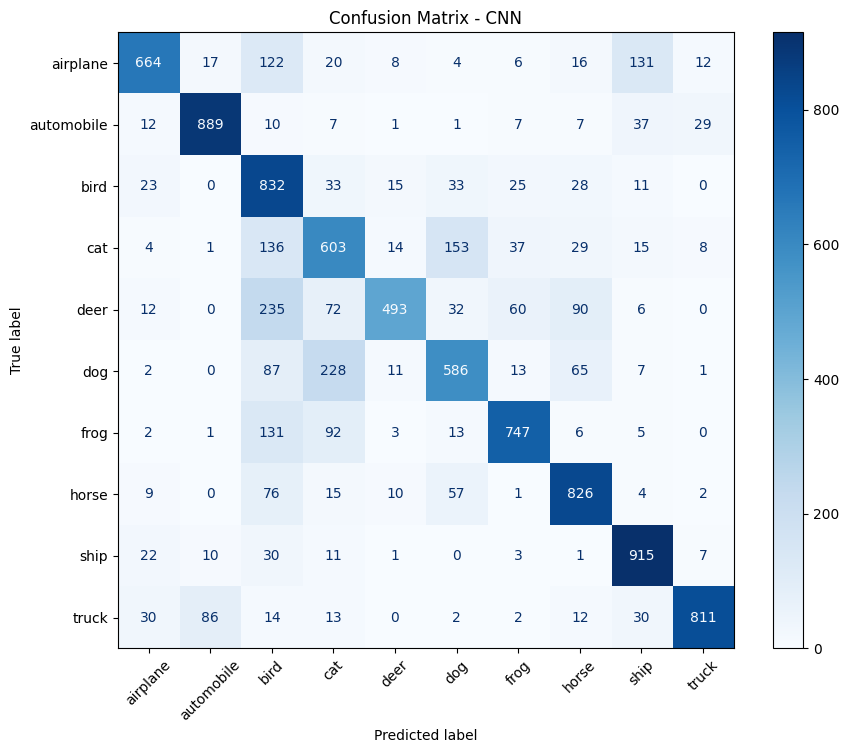

In [15]:
cnn_pred, cnn_accuracy = evaluate_model(
    cnn_model,
    X_test_norm,
    y_test_cat,
    y_test_flat,
    "CNN"
)

## **11. Build ResNet-style model**

In [16]:
def residual_block(x, filters, stride=1):
    """Small residual block suitable for CIFAR-10 images."""
    shortcut = x

    x = Conv2D(
        filters,
        (3, 3),
        strides=stride,
        padding="same",
        use_bias=False
    )(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = Conv2D(
        filters,
        (3, 3),
        strides=1,
        padding="same",
        use_bias=False
    )(x)
    x = BatchNormalization()(x)

    # Match shortcut shape when filters or spatial size change
    if stride != 1 or int(shortcut.shape[-1]) != filters:
        shortcut = Conv2D(
            filters,
            (1, 1),
            strides=stride,
            padding="same",
            use_bias=False
        )(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = Activation("relu")(x)

    return x


def build_resnet_style_model(input_shape=(32, 32, 3), num_classes=10):
    inputs = Input(shape=input_shape)

    x = Conv2D(32, (3, 3), padding="same", use_bias=False)(inputs)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    # Residual stages
    x = residual_block(x, 32, stride=1)
    x = residual_block(x, 32, stride=1)

    x = residual_block(x, 64, stride=2)
    x = residual_block(x, 64, stride=1)

    x = residual_block(x, 128, stride=2)
    x = residual_block(x, 128, stride=1)

    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.40)(x)
    outputs = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs=inputs, outputs=outputs, name="ResNet_Style_CIFAR10")

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


resnet_model = build_resnet_style_model(num_classes=NUM_CLASSES)
resnet_model.summary()

Model: "ResNet_Style_CIFAR10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_6        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │      9,216 │ activation_6[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 32, 32,    │      9,216 │ activation_7[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ activation_6[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_8        │ (None, 32, 32,    │          0 │ add[0][0]         │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 32, 32,    │      9,216 │ activation_8[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_9[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 32, 32,    │      9,216 │ activation_9[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_10[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 32, 32,    │          0 │ batch_normalizat

 Total params: 698,858 (2.67 MB)

 Trainable params: 696,618 (2.66 MB)

 Non-trainable params: 2,240 (8.75 KB)

## **12. Train ResNet model**

In [17]:
# You can increase epochs for better accuracy.
# ResNet-style model may need a little more training than CNN.

RESNET_EPOCHS = 12

resnet_callbacks = [
    EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]

resnet_history = resnet_model.fit(
    X_train_norm,
    y_train_cat,
    validation_split=0.2,
    epochs=RESNET_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=resnet_callbacks,
    verbose=1
)

Epoch 1/12
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 27ms/step - accuracy: 0.4509 - loss: 1.5121 - val_accuracy: 0.3697 - val_loss: 2.1298 - learning_rate: 0.0010
Epoch 2/12
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.6417 - loss: 1.0112 - val_accuracy: 0.6124 - val_loss: 1.0639 - learning_rate: 0.0010
Epoch 3/12
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.7201 - loss: 0.8072 - val_accuracy: 0.6436 - val_loss: 0.9691 - learning_rate: 0.0010
Epoch 4/12
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - accuracy: 0.7684 - loss: 0.6675 - val_accuracy: 0.5439 - val_loss: 1.4836 - learning_rate: 0.0010
Epoch 5/12
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.8117 - loss: 0.5545 - val_accuracy: 0.5664 - val_loss: 1.2899 - learning_rate: 0.0010
Epoch 6/12
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.8708 - loss: 0.3867 - val_accuracy: 0.7054 - val_loss: 0.9503 - learning_rate: 5.0000e-04
Epoch 7/12
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.8990

## **13. Evaluate ResNet model**


===== ResNet-style Evaluation =====
Test Loss: 0.7558
Test Accuracy: 0.8116

Classification Report:
              precision    recall  f1-score   support

    airplane       0.85      0.80      0.82      1000
  automobile       0.94      0.88      0.91      1000
        bird       0.74      0.76      0.75      1000
         cat       0.62      0.69      0.65      1000
        deer       0.84      0.75      0.79      1000
         dog       0.79      0.66      0.72      1000
        frog       0.79      0.90      0.84      1000
       horse       0.91      0.81      0.86      1000
        ship       0.88      0.92      0.90      1000
       truck       0.82      0.94      0.87      1000

    accuracy                           0.81     10000
   macro avg       0.82      0.81      0.81     10000
weighted avg       0.82      0.81      0.81     10000



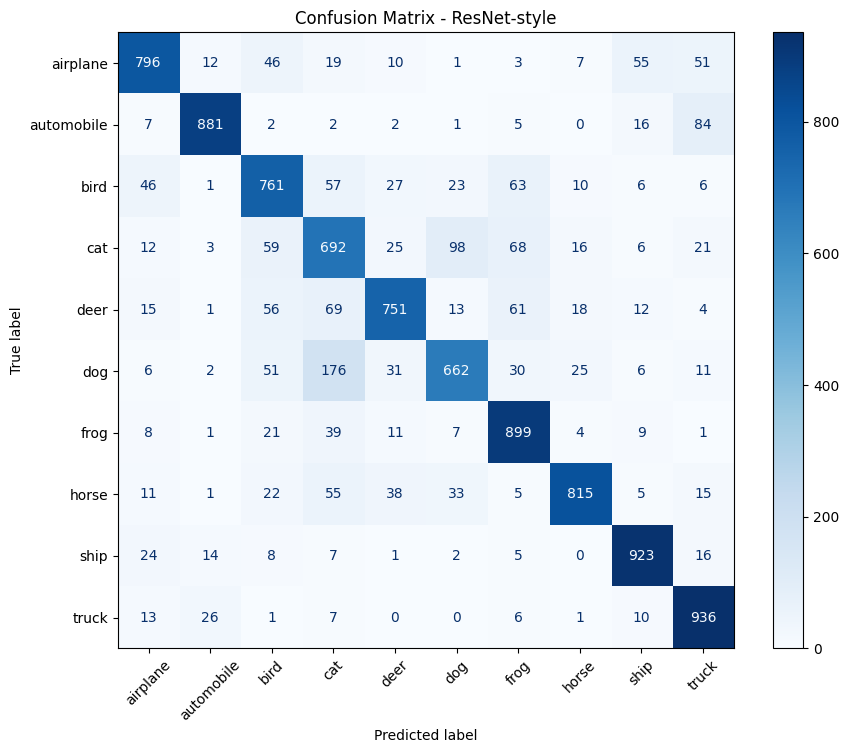

In [18]:
resnet_pred, resnet_accuracy = evaluate_model(
    resnet_model,
    X_test_norm,
    y_test_cat,
    y_test_flat,
    "ResNet-style"
)

## **14. Compare CNN vs ResNet accuracy**




,Model,Test Loss,Test Accuracy
0,CNN,0.721550,0.7366
1,ResNet-style,0.755824,0.8116


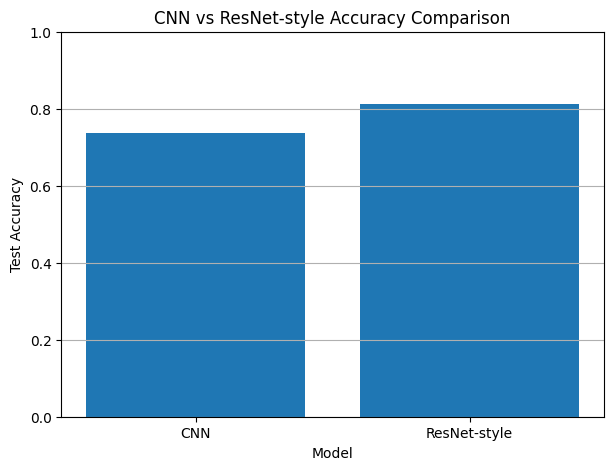

Best performing model: ResNet-style


In [19]:
comparison_df = pd.DataFrame(model_results).T.reset_index()
comparison_df = comparison_df.rename(columns={"index": "Model"})

display(comparison_df)

plt.figure(figsize=(7, 5))
plt.bar(comparison_df["Model"], comparison_df["Test Accuracy"])
plt.title("CNN vs ResNet-style Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.show()

best_model_name = comparison_df.sort_values("Test Accuracy", ascending=False).iloc[0]["Model"]
print("Best performing model:", best_model_name)

## **15. Plot accuracy/loss graphs**

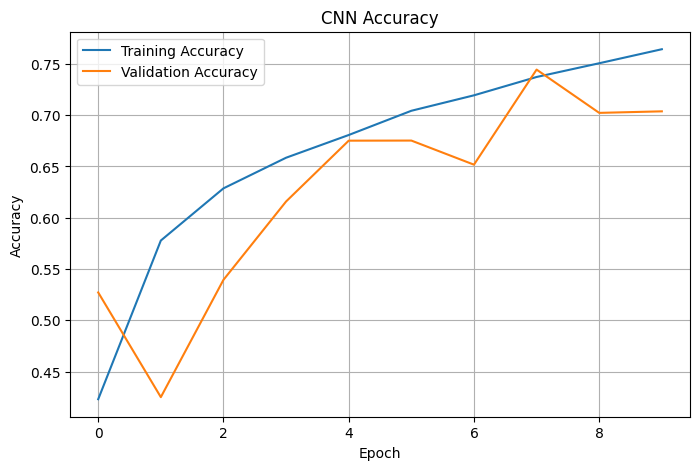

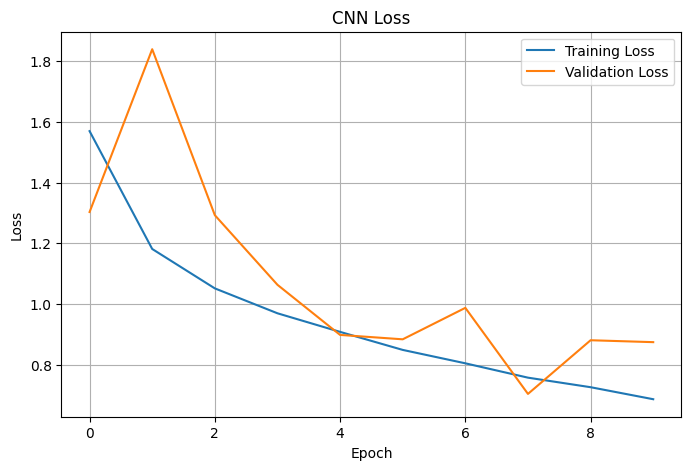

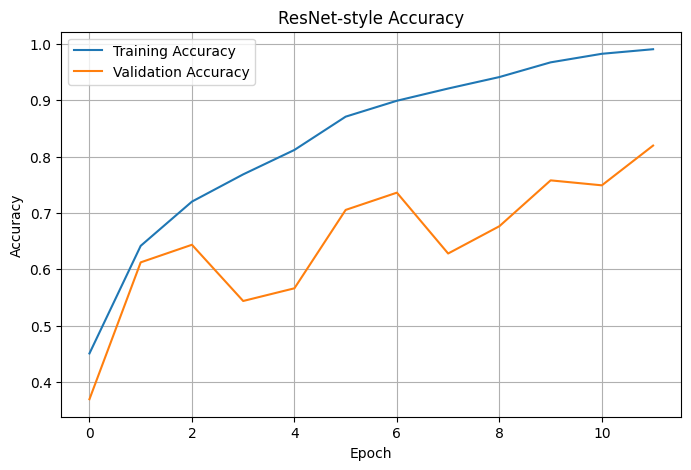

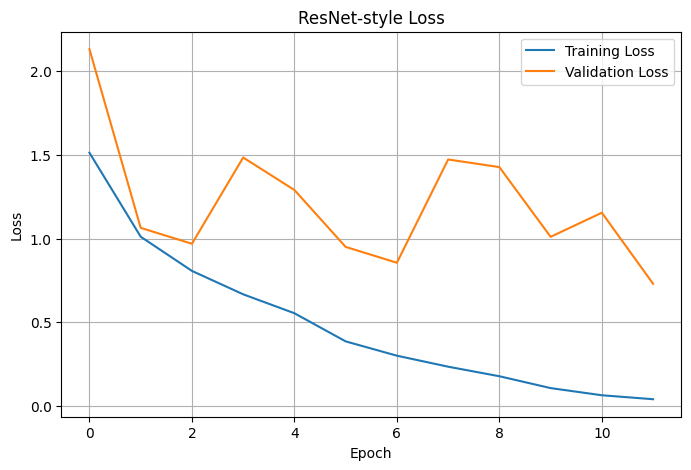

In [20]:
plot_training_history(cnn_history, "CNN")
plot_training_history(resnet_history, "ResNet-style")

## **16. Confusion matrix**

CNN Confusion Matrix

===== CNN Evaluation =====
Test Loss: 0.7216
Test Accuracy: 0.7366

Classification Report:
              precision    recall  f1-score   support

    airplane       0.85      0.66      0.75      1000
  automobile       0.89      0.89      0.89      1000
        bird       0.50      0.83      0.62      1000
         cat       0.55      0.60      0.58      1000
        deer       0.89      0.49      0.63      1000
         dog       0.67      0.59      0.62      1000
        frog       0.83      0.75      0.79      1000
       horse       0.76      0.83      0.79      1000
        ship       0.79      0.92      0.85      1000
       truck       0.93      0.81      0.87      1000

    accuracy                           0.74     10000
   macro avg       0.77      0.74      0.74     10000
weighted avg       0.77      0.74      0.74     10000



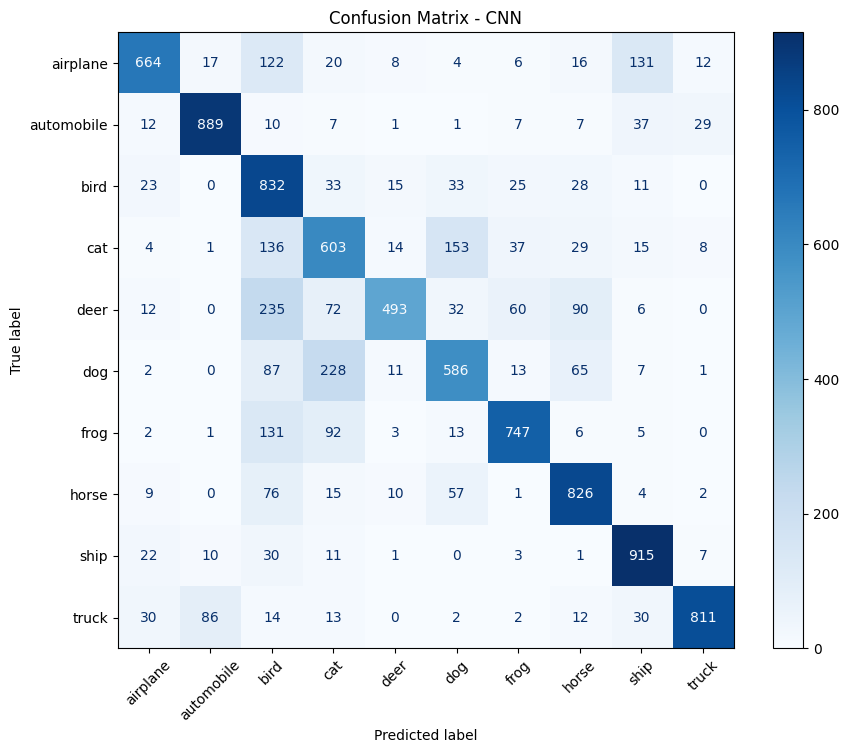


ResNet-style Confusion Matrix

===== ResNet-style Evaluation =====
Test Loss: 0.7558
Test Accuracy: 0.8116

Classification Report:
              precision    recall  f1-score   support

    airplane       0.85      0.80      0.82      1000
  automobile       0.94      0.88      0.91      1000
        bird       0.74      0.76      0.75      1000
         cat       0.62      0.69      0.65      1000
        deer       0.84      0.75      0.79      1000
         dog       0.79      0.66      0.72      1000
        frog       0.79      0.90      0.84      1000
       horse       0.91      0.81      0.86      1000
        ship       0.88      0.92      0.90      1000
       truck       0.82      0.94      0.87      1000

    accuracy                           0.81     10000
   macro avg       0.82      0.81      0.81     10000
weighted avg       0.82      0.81      0.81     10000



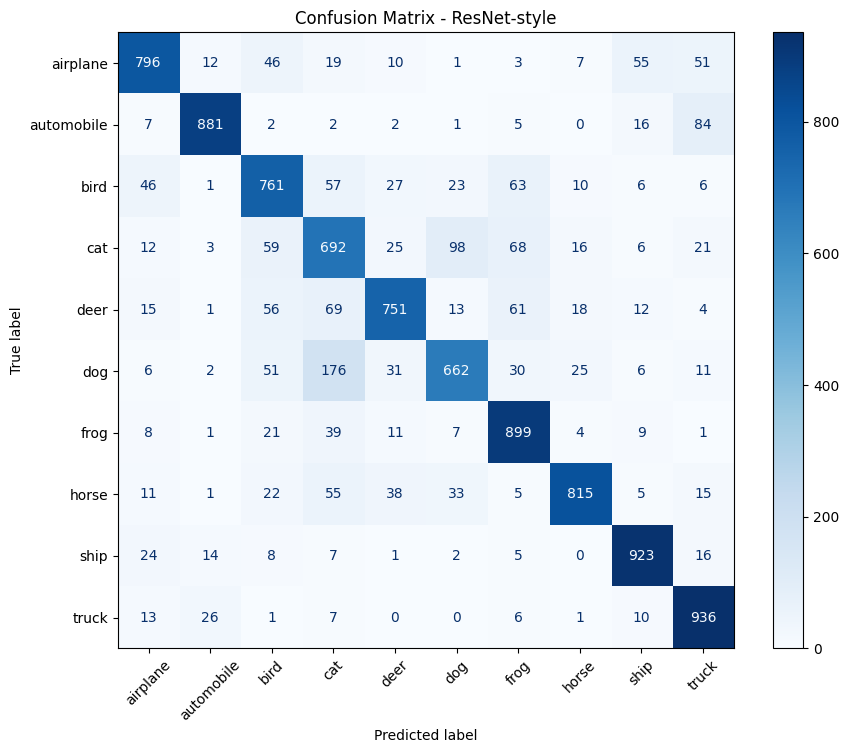

In [21]:
# Confusion matrices were already shown in the evaluation cells.
# This cell displays them again for both models.

print("CNN Confusion Matrix")
_ = evaluate_model(cnn_model, X_test_norm, y_test_cat, y_test_flat, "CNN", show_matrix=True)

print("\nResNet-style Confusion Matrix")
_ = evaluate_model(resnet_model, X_test_norm, y_test_cat, y_test_flat, "ResNet-style", show_matrix=True)

## **17. Classification report**

In [22]:
# Classification reports were already printed in the evaluation cells.
# This separate cell generates reports again in a clean format.

cnn_pred_prob = cnn_model.predict(X_test_norm, verbose=0)
cnn_pred_labels = np.argmax(cnn_pred_prob, axis=1)

resnet_pred_prob = resnet_model.predict(X_test_norm, verbose=0)
resnet_pred_labels = np.argmax(resnet_pred_prob, axis=1)

print("===== CNN Classification Report =====")
print(
    classification_report(
        y_test_flat,
        cnn_pred_labels,
        labels=list(range(NUM_CLASSES)),
        target_names=CLASS_NAMES,
        zero_division=0
    )
)

print("===== ResNet-style Classification Report =====")
print(
    classification_report(
        y_test_flat,
        resnet_pred_labels,
        labels=list(range(NUM_CLASSES)),
        target_names=CLASS_NAMES,
        zero_division=0
    )
)

===== CNN Classification Report =====
              precision    recall  f1-score   support

    airplane       0.85      0.66      0.75      1000
  automobile       0.89      0.89      0.89      1000
        bird       0.50      0.83      0.62      1000
         cat       0.55      0.60      0.58      1000
        deer       0.89      0.49      0.63      1000
         dog       0.67      0.59      0.62      1000
        frog       0.83      0.75      0.79      1000
       horse       0.76      0.83      0.79      1000
        ship       0.79      0.92      0.85      1000
       truck       0.93      0.81      0.87      1000

    accuracy                           0.74     10000
   macro avg       0.77      0.74      0.74     10000
weighted avg       0.77      0.74      0.74     10000

===== ResNet-style Classification Report =====
              precision    recall  f1-score   support

    airplane       0.85      0.80      0.82      1000
  automobile       0.94      0.88      0.91    

## **18. Test model on random images**

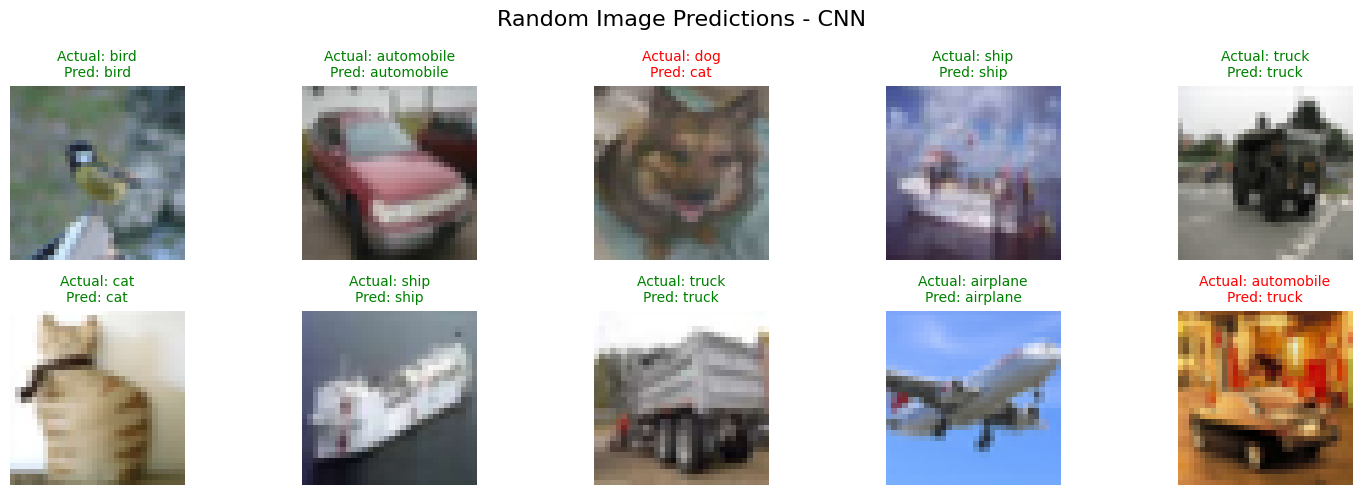

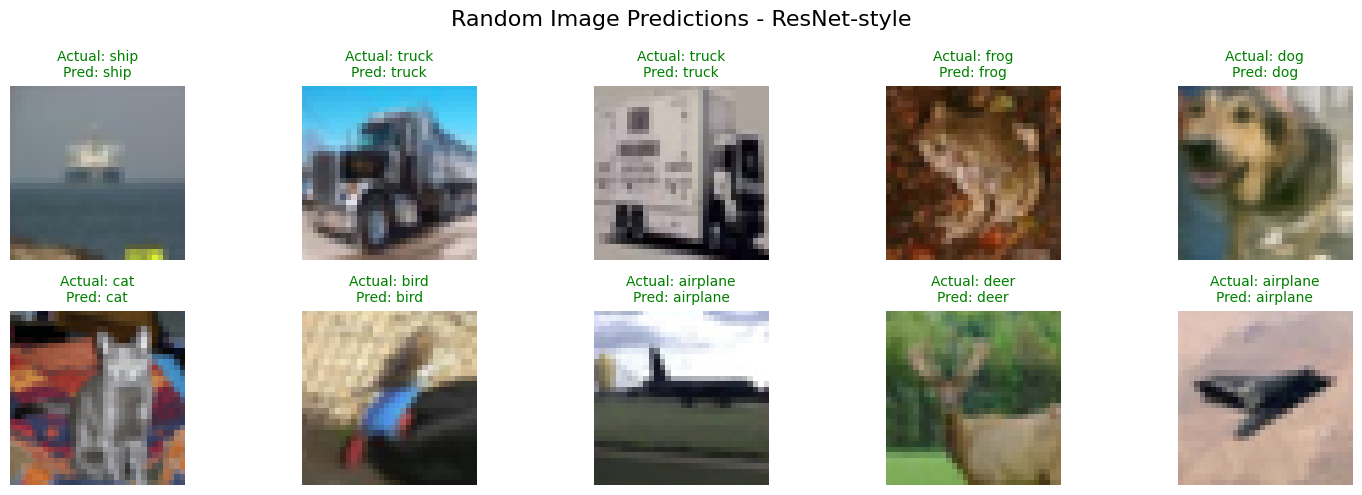

In [23]:
show_random_predictions(
    cnn_model,
    X_test_norm,
    y_test_flat,
    "CNN",
    total_images=10
)

show_random_predictions(
    resnet_model,
    X_test_norm,
    y_test_flat,
    "ResNet-style",
    total_images=10
)

## **19. Save models**

In [24]:
# Save models in Keras format
cnn_model.save("cifar10_cnn_model.keras")
resnet_model.save("cifar10_resnet_style_model.keras")

print("Models saved successfully!")
print("Saved files:")
print("- cifar10_cnn_model.keras")
print("- cifar10_resnet_style_model.keras")

# Optional: download models automatically in Google Colab
try:
    from google.colab import files
    files.download("cifar10_cnn_model.keras")
    files.download("cifar10_resnet_style_model.keras")
except Exception as e:
    print("Automatic download is available only in Google Colab.")
    print("You can manually download the saved model files from the Files panel.")

Models saved successfully!
Saved files:
- cifar10_cnn_model.keras
- cifar10_resnet_style_model.keras


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Final Notes

- The CNN model is a custom convolutional neural network built from scratch.
- The ResNet-style model uses residual connections to improve gradient flow and feature learning.
- Both models are trained and evaluated on the same CIFAR-10 dataset.
- Final comparison is based on test accuracy, classification report, and confusion matrix.